In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import statsmodels.formula.api as smf
import pingouin as pg
import seaborn as sb
plt.style.use('/Users/amonast/Documents/GitHub/CA1_Engram_Dynamics/figures/paper_style.mplstyle')


/Users/amonast/opt/anaconda3/envs/caiman/lib/python3.10/site-packages/outdated/utils.py:14: OutdatedPackageWarning: The package pingouin is out of date. Your version is 0.5.3, the latest is 0.6.1.
Set the environment variable OUTDATED_IGNORE=1 to disable these warnings.
  return warn(


In [2]:
palette = {
    'engram': '#F37243',     
    'non_engram': '#00ABC8'}


In [3]:
data = pd.read_csv('/Volumes/AM_SSD1/Spont2P/Analysis/networks/rieman_distance_rest_matched.csv',)
data['animal_fov'] =data['animal']+'_'+data['fov']

In [4]:
data.head()

,animal,fov,group,population,riem_dist,animal_fov
0,149L,FOV1,FC,engram,0.115448,149L_FOV1
1,149L,FOV2,FC,engram,0.066595,149L_FOV2
2,034R,FOV1,HC,engram,0.125698,034R_FOV1
3,146R,FOV2,FC,engram,0.047571,146R_FOV2
4,217N,FOV1,HC,engram,0.072514,217N_FOV1


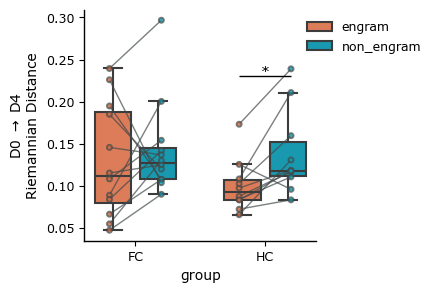

In [16]:
gray = '#424949'
fig, ax = plt.subplots(figsize=(3, 3))

sb.boxplot(data=data, hue='population', y='riem_dist', x='group', ax=ax,gap=0.2,
           palette=palette, width=.7, linewidth=1.5, showfliers=False)
sb.stripplot(data=data, hue='population', x='group',y='riem_dist', ax=ax, palette=palette,
             edgecolor=gray, linewidth=1.5, dodge=True, jitter=0, alpha=.7, size=3.5, legend=False)

for g in data['group'].unique():
    x_e,x_ne = (-0.2, 0.2) if g == 'FC' else (0.8, 1.2)
    grp = data[data['group'] == g]
    for _, pair in grp.groupby(['animal', 'fov']):
        e_val  = pair[pair['population'] == 'engram']['riem_dist']
        ne_val = pair[pair['population'] == 'non_engram']['riem_dist']
        if not e_val.empty and not ne_val.empty:
            ax.plot([x_ne, x_e], [ne_val.values[0], e_val.values[0]],
                    color=gray, linewidth=1, alpha=0.7)
ax.set_ylabel('D0 $\\rightarrow$ D4 \nRiemannian Distance')
#ax.set_ylim(0.02,.2)
plt.hlines(.23,.8,1.2,colors='k',linewidth=1)
plt.text(1,.23,s='*',ha='center')
ax.legend(bbox_to_anchor=(1.5,1),frameon=False)
sb.despine()
plt.savefig('Fig4B_RiemanDist_rest.svg',transparent=True)

In [12]:
model = smf.mixedlm("riem_dist ~ group * population",
            data=data,groups=data['animal_fov']).fit()
model.summary()

/Users/amonast/opt/anaconda3/envs/caiman/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


<class 'statsmodels.iolib.summary2.Summary'>
"""
                     Mixed Linear Model Regression Results
===============================================================================
Model:                    MixedLM         Dependent Variable:         riem_dist
No. Observations:         44              Method:                     REML     
No. Groups:               22              Scale:                      0.0017   
Min. group size:          2               Log-Likelihood:             57.3164  
Max. group size:          2               Converged:                  Yes      
Mean group size:          2.0                                                  
-------------------------------------------------------------------------------
                                     Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-------------------------------------------------------------------------------
Intercept                             0.130    0.016  8.357 0.000  0.099  0.160
group[T.HC]                          -0.030    0.023 -1.286 0.198 -0.075  0.016
population[T.non_engram]              0.013    0.017  0.786 0.432 -0.020  0.046
group[T.HC]:population[T.non_engram]  0.025    0.025  1.016 0.310 -0.023  0.074
Group Var                             0.001    0.023                           
===============================================================================

"""

In [13]:
pg.mixed_anova(data=data,dv='riem_dist',between='group',within='population',subject='animal_fov')

,Source,SS,DF1,DF2,MS,F,p-unc,np2,eps
0,group,0.003174,1,20,0.003174,0.770517,0.390480,0.037097,NaN
1,population,0.006632,1,20,0.006632,3.967703,0.060212,0.165544,1.0
2,Interaction,0.001726,1,20,0.001726,1.032268,0.321761,0.049080,NaN


In [19]:
pg.pairwise_tests(data=data,dv='riem_dist',between='group',
                  within='population',subject='animal_fov',
                  padjust='fdr_bh',within_first=False,parametric=False,)

/Users/amonast/opt/anaconda3/envs/caiman/lib/python3.10/site-packages/pingouin/pairwise.py:478: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  tmp = data.groupby([subject, f], as_index=False, observed=True, sort=True).mean()
/Users/amonast/opt/anaconda3/envs/caiman/lib/python3.10/site-packages/pingouin/pairwise.py:583: FutureWarning: In a future version, `df.iloc[:, i] = newvals` will attempt to set the values inplace instead of always setting a new array. To retain the old behavior, use either `df[df.columns[i]] = newvals` or, if columns are non-unique, `df.isetitem(i, newvals)`
  stats.loc[:, "Parametric"] = parametric


,Contrast,group,A,B,Paired,Parametric,U-val,W-val,alternative,p-unc,p-corr,p-adjust,hedges
0,group,-,FC,HC,False,False,75.0,NaN,two-sided,0.339021,NaN,NaN,0.361575
1,population,-,engram,non_engram,True,False,NaN,64.0,two-sided,0.042498,NaN,NaN,-0.449804
2,group * population,FC,engram,non_engram,True,False,NaN,31.0,two-sided,0.569336,0.569336,fdr_bh,-0.204525
3,group * population,HC,engram,non_engram,True,False,NaN,5.0,two-sided,0.019531,0.039062,fdr_bh,-0.877771


In [15]:
data['animal_fov'].loc[data['group']=='FC'].unique()

array(['149L_FOV1', '149L_FOV2', '146R_FOV2', '989N_FOV1', '989N_FOV2',
       '9972R_FOV1', '9972R_FOV2', '160R_FOV1', '160R_FOV2', '493R_FOV1',
       '492N_FOV1', '492N_FOV2'], dtype=object)

In [10]:
data['animal_fov'].loc[data['group']=='HC'].unique()

array(['034R_FOV1', '217N_FOV1', '217N_FOV2', '217R_FOV1', '218L_FOV1',
       '218L_FOV2', '994R_FOV1', '994R_FOV2', '1912L_FOV1', '1912L_FOV2'],
      dtype=object)